In [2]:
import sys
sys.path.append("/Users/sujaladhikari/Sujal's Personal/Projects/FedIDS")

In [3]:
import os 
import shutil
import numpy as np 
import pandas as pd 
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import torch 
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from Model.model import MLP
from torch.optim import Adam
import utils
from utils import JoinCustomDataset
from sklearn.metrics import classification_report
from federatedlearning import updatefrom_local, weight_averaging
from nids_training import evaluate_model
import matplotlib.pyplot as plt 
import random 

### Setting up the device

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device
RANDOMSEED = 42
random.seed(RANDOMSEED)
np.random.seed(RANDOMSEED)
torch.manual_seed(RANDOMSEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(RANDOMSEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
### Creating a generator to pass into the data loader 
g = torch.Generator()
g.manual_seed(RANDOMSEED)

### Creating the global model - using the same MLP used for the centralized model 

In [5]:
input_size = 78
hidden_layer = [256, 128,64,8]
num_classes = 2
global_model = MLP(input_size, hidden_layer,num_classes).to(device)
global_model
num_clients = 4

### Creating two folders that holds the training input data, and the other holds the result 

In [6]:
manual = ['One', 'Two', 'Three' , 'Four']
types = ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']
source_directory = '../silos_datasets/'
destination_directory  = './client_data/nids/' ## We are creating sub-directory in order to check on the future datasets.
os.makedirs(destination_directory , exist_ok=True)
for index,centralized_test_loss in enumerate(manual):
    new_client_name = f'client_{index}'
    for type in types:
        old_file = f'silo{centralized_test_loss}_{type}.csv'
        old_filepath = os.path.join(source_directory, old_file)
        
        new_file = f'{new_client_name}_{type}.csv'
        new_filepath = os.path.join(destination_directory , new_file)

        if os.path.exists(old_filepath):
            shutil.copy(old_filepath, new_filepath)

saving_directory = os.path.join('./output_nids/DNN_fedavg/nids') ## Creating the folder that stores the result of each client performance 
os.makedirs(saving_directory, exist_ok=True)

### Creating the Data Configuration and Training Configuration 


In [7]:
batch_size = 64 ## Initially we set up as same as the centralized model 
lr = 1e-2 ## different learning rate
num_rounds = 20 ## 5/.0001 => 50000 rounds 
num_local_epochs = 1
save_interval = 1

### We will be creating new dataset which contains all the testing data, that will keep on checking on how the global model is performing !?

### This will be the golden dataset that will contain 50% of the randomly sampled data from each of the testing data of the clients, and to make it more further we will be shuffling the data and will take the 100% of the whole shuffle data !

In [8]:
## Creating an ultimate gloden dataset 
golden_data = []
path = './client_data/nids/'
for i in range(num_clients):
    filepath = os.path.join(path, f'client_{i}_X_test.csv')
    testfilepath = os.path.join(path, f'client_{i}_y_test.csv')
    if os.path.exists(filepath) and os.path.exists(testfilepath):
        x_test_data = pd.read_csv(filepath)
        test_data = pd.read_csv(testfilepath)
        combined_data = pd.concat([x_test_data,test_data], axis = 1)
        golden_data.append(combined_data)


global_dataset = pd.concat(golden_data, ignore_index=True)
## Randomly shuffling the dataset 
global_dataset = global_dataset.sample(frac = 1, random_state = RANDOMSEED).reset_index(drop = True)
global_dataset.to_csv('../datasets/global_test_dataset.csv', index = False)
global_dataset.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label_Binary
0,-0.135189,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
1,-0.416792,1.913036,0.019771,0.018355,0.090779,-0.002716,0.419670,-0.258335,0.102476,0.316994,...,0.003116,-0.072992,0.060094,-0.005568,-0.085019,0.356508,-0.155389,0.258998,0.444437,0
2,-0.317572,-0.751546,-0.018182,-0.012594,-0.113059,-0.011345,-0.353239,0.267224,-0.176562,-0.375043,...,0.003061,-0.137113,-0.099480,-0.150381,-0.110743,-0.686650,-0.121376,-0.693794,-0.674594,0
3,-0.410492,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
4,-0.439214,-0.349547,-0.005928,-0.010028,-0.077591,-0.006223,-0.204675,-0.258335,-0.232585,-0.172305,...,0.003116,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,0


### Two Global Metrics for the global model 

In [9]:
performance_dict, performance_log = dict(), dict()
metric_keys = ['g_train_loss', 'g_test_loss']
performance_dict, performance_log = utils.performance_analyzer(metric_keys)

In [10]:
labmda = 0.01

### Loading all the client data before training them to the global model 


In [11]:
client_loaders = [] ## It has four dataloaders for each client 
for index in range(num_clients):
    features_path = f'client_{index}_X_train.csv'
    labels_path = f'client_{index}_y_train.csv'
    features_directory = os.path.join(destination_directory, features_path )
    labels_directory = os.path.join(destination_directory, labels_path) 
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True,generator=g) ## The batch size is 64
    client_loaders.append(dataloader)


### Creating a test loader for each client to check the test loss 

In [12]:
validation_loaders = []
for index in range(num_clients):
    features_path = f'client_{index}_X_val.csv'
    labels_path = f'client_{index}_y_val.csv'
    features_directory = os.path.join(destination_directory, features_path )
    labels_directory = os.path.join(destination_directory, labels_path)
    print(features_directory,labels_directory)
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True,generator=g)
    validation_loaders.append(dataloader)

./client_data/nids/client_0_X_val.csv ./client_data/nids/client_0_y_val.csv
./client_data/nids/client_1_X_val.csv ./client_data/nids/client_1_y_val.csv
./client_data/nids/client_2_X_val.csv ./client_data/nids/client_2_y_val.csv
./client_data/nids/client_3_X_val.csv ./client_data/nids/client_3_y_val.csv


### Automatically resuming from the checkpoint 


In [13]:
# Checking if there is already anything going on 
log_path = os.path.join(saving_directory, 'performanance_log.pickle')
if os.path.isfile(log_path):
    performance_log = utils.loading_pickle(log_path)
starting_round = len(performance_log[metric_keys[0]]) ## Check the list of the stored values (g_train), if the value is greaeter thean 0 then the model is already started and doing its job, and if the model crashes then it can continue from where it left!
if starting_round > 0:
    global_model.load_state_dict(torch.load(os.path.join(saving_directory, 'g_r_{}.pth').format(starting_round))) ## The global model takes the weight from where it left 

In [14]:
global_weights = global_model.state_dict() ## This gives the initial weights of the given model
loss_function = nn.CrossEntropyLoss()
optimization_args = {'lr':lr}

### Starting of the model 

### We wll be looping the model from start round to number of rounds
### Here the starting round is initially zero as nothing is loaded in the given model 

for round_number in range(starting_round, num_rounds): ## Initially 0 -> 5
    print('Round Number:', round_number) 
    global_model.train()
    client_updates = dict() ## We will be storing the updates given by clients in a dictionary 
    for client_number in range(num_clients): ## Looping through each client
        print('Client:', client_number) ## Printing out the client number 
        client_loader = client_loaders[client_number] ## Loading the each client data 
        validation_loader = validation_loaders[client_number] ## Loading each validation data 
        client_update = updatefrom_local(global_model,client_loader, validation_loader, num_local_epochs, optimization_args) 
        client_updates.setdefault('local_weights', list()).append(client_update['local_weights'])
        client_updates.setdefault('num_samples', list()).append(client_update['num_samples'])

        ## Performance log update 
        performance_log.setdefault('c_{}_train_loss'.format(client_number), list()).append(client_update['train_loss'])
        ## Train loss of each client using the global model on training data 
        performance_log.setdefault('c_{}_test_loss'.format(client_number), list()).append(client_update['test_loss'])

    
    global_weights = weight_averaging(client_updates['local_weights'], client_updates['num_samples'], device)
    global_model.load_state_dict(global_weights) ## Updating the weights to the global model 

    ## Evaluating the global model on local dataset in each round 
    for client_index in range(num_clients):
        g_train_loss = evaluate_model(global_model, client_loaders[client_index], loss_function, tqdm_desc = 'g_train_loss')
        performance_dict['g_train_loss'].update_state(g_train_loss)
        g_test_loss = evaluate_model(global_model, validation_loaders[client_index], loss_function, tqdm_desc='Validation Loss' )
        performance_dict['g_test_loss'].update_state(g_test_loss)
    
    performance_log['g_train_loss'].append(performance_dict['g_train_loss'].result())
    performance_log['g_test_loss'].append(performance_dict['g_test_loss'].result())
    performance_dict['g_train_loss'].reset_state()
    performance_dict['g_test_loss'].reset_state()

    for metric in metric_keys:
        print(f"{metric}: {performance_log[metric][-1]}")

    ## Saving the global model 

    if (round_number + 1)  % save_interval == 0: 
        torch.save(global_model.state_dict(), os.path.join(saving_directory, 'g_r_{}.pth'.format(round_number+1))) ## Saving the global model's weights in the given directory with the name g_r_1..n.pth
        utils.savein_pickle(log_path,performance_log)  ## Storing the overall value in the pickle form to access it later 
    

### The global weight is updated in each round where the weight of each client for each layer is stored in the client updates which is then sent to weight_averaging which averages the weight based on the samples size


### Making a dataframe that stores all the test loss and train loss of each client and global model in each round



In [15]:
import pickle
with open('./output_nids/DNN_fedavg/nids/performanance_log.pickle', 'rb') as f:
    losses = pickle.load(f)

data = pd.DataFrame(losses)
data.index.name = 'Round'
data = data.reset_index()
data.head(5)

,Round,g_train_loss,g_test_loss,c_0_train_loss,c_0_test_loss,c_1_train_loss,c_1_test_loss,c_2_train_loss,c_2_test_loss,c_3_train_loss,c_3_test_loss
0,0,0.873810,0.907346,0.033005,0.033507,0.045839,0.045184,0.046098,0.048453,0.677179,0.676216
1,1,1.137079,1.195992,0.041361,0.042496,0.044627,0.043881,0.028187,0.031042,0.055816,0.362471
2,2,1.214783,1.288290,0.031198,0.031637,0.037880,0.037989,0.028700,0.031691,0.049296,0.657034
3,3,1.178931,1.216085,0.028983,0.029911,0.041269,0.040785,0.021426,0.026935,0.049293,0.964303
4,4,1.266320,1.318874,0.030051,0.030685,0.036680,0.036462,0.023945,0.031245,0.050323,1.132012


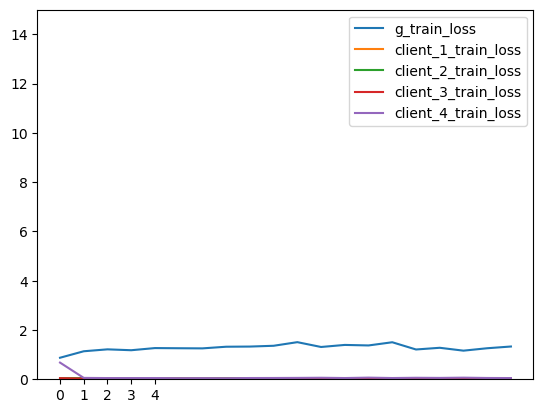

In [16]:
plt.plot(data['g_train_loss'], label = 'g_train_loss')
plt.plot(data['c_0_train_loss'], label = 'client_1_train_loss')
plt.plot(data['c_1_train_loss'], label = 'client_2_train_loss')
plt.plot(data['c_2_train_loss'], label = 'client_3_train_loss')
plt.plot(data['c_3_train_loss'], label = 'client_4_train_loss')
plt.xticks(np.arange(0,5,1))
plt.ylim(0,15)
plt.legend()
plt.show()

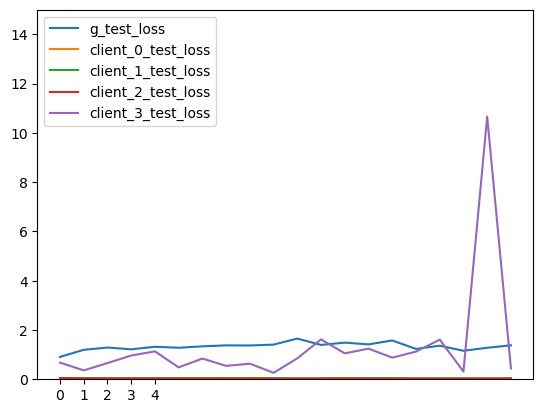

In [17]:
plt.plot(data['g_test_loss'], label = 'g_test_loss')
plt.plot(data['c_0_test_loss'], label = 'client_0_test_loss')
plt.plot(data['c_1_test_loss'], label = 'client_1_test_loss')
plt.plot(data['c_2_test_loss'], label = 'client_2_test_loss')
plt.plot(data['c_3_test_loss'], label = 'client_3_test_loss')
plt.xticks(np.arange(0,5,1))
plt.ylim(0,15)
plt.legend()
plt.show()

In [18]:
print(global_model)
print(global_model.state_dict())

MLP(
  (fc_layers): ModuleList(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.001)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.001)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LeakyReLU(negative_slope=0.001)
    (6): Linear(in_features=64, out_features=8, bias=True)
    (7): LeakyReLU(negative_slope=0.001)
    (8): Linear(in_features=8, out_features=2, bias=True)
  )
)
OrderedDict([('fc_layers.0.weight', tensor([[ 0.1632,  0.0718, -0.0580,  ..., -0.0526, -0.0826,  0.0248],
        [ 0.2156,  0.0467, -0.0588,  ..., -0.1186,  0.1287, -0.0496],
        [ 0.0324,  0.0288,  0.0421,  ...,  0.0623,  0.0997,  0.1465],
        ...,
        [ 0.0207,  0.0890, -0.0600,  ...,  0.0948, -0.0130,  0.0941],
        [ 0.0353, -0.1214, -0.1528,  ..., -0.0818, -0.0563,  0.0219],
        [-0.0026, -0.0252,  0.0337,  ..., -0.0835,  0.0430, -0.1582]],
       device='mps:0')), ('

---
### Evaluating the global model on combined test data vs individual datas

In [19]:
criterion = nn.CrossEntropyLoss()
def post_trained_global_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    total = 0 
    correct = 0 
    true_labels = []
    prediction = []

    with torch.no_grad():
        for samples, features in test_loader:
            samples = samples.to(device)
            features = features.to(device)
            output = model(samples)
            loss = criterion(output, features)
            _, predicted = output.max(1)
            prediction.extend(predicted.tolist())
            total += features.size(0)
            test_loss += loss.item()
            correct += predicted.eq(features).sum().item()
            true_labels.extend(features.tolist())

        test_loss = test_loss/len(test_loader.dataset)
        accuracy = 100* correct / total 
    
    return test_loss, accuracy, prediction, true_labels

In [20]:
global_dataset.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label_Binary
0,-0.135189,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
1,-0.416792,1.913036,0.019771,0.018355,0.090779,-0.002716,0.419670,-0.258335,0.102476,0.316994,...,0.003116,-0.072992,0.060094,-0.005568,-0.085019,0.356508,-0.155389,0.258998,0.444437,0
2,-0.317572,-0.751546,-0.018182,-0.012594,-0.113059,-0.011345,-0.353239,0.267224,-0.176562,-0.375043,...,0.003061,-0.137113,-0.099480,-0.150381,-0.110743,-0.686650,-0.121376,-0.693794,-0.674594,0
3,-0.410492,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
4,-0.439214,-0.349547,-0.005928,-0.010028,-0.077591,-0.006223,-0.204675,-0.258335,-0.232585,-0.172305,...,0.003116,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,0


### Creating the global dataset loader

In [21]:
## Converting the global tumple to the dataloader
scaler = StandardScaler()
X = global_dataset.drop(columns ='Label_Binary')
X = X.to_numpy()
y = global_dataset['Label_Binary']
y = y.to_numpy()
X_tensor = torch.tensor(X, dtype = torch.float32)
y_tensor = torch.tensor(y, dtype = torch.long)
global_tuple = TensorDataset(X_tensor,y_tensor)
test_loader = DataLoader(global_tuple, batch_size=batch_size, shuffle=True,generator=g)
global_test_loss, global_accuracy, prediction, true_labels = post_trained_global_model(global_model, test_loader,criterion,device)

In [22]:
print(f"The test loss: {global_test_loss}")
print(f"The accuracy :{global_accuracy}")


The test loss: 0.001937027725109464
The accuracy :96.48034118408127


In [23]:
### Classification matrix
report = classification_report(prediction, true_labels)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.95      0.97     86044
           1       0.95      0.98      0.96     80904

    accuracy                           0.96    166948
   macro avg       0.96      0.97      0.96    166948
weighted avg       0.97      0.96      0.96    166948



In [24]:
centralized_model = utils.loading_pickle('../models/centralized_model.pickle')
centralized_model = centralized_model.to(device)
centralized_test_loss,centralized_accuracy,centralized_predictions,centralized_true_labels = post_trained_global_model(centralized_model, test_loader, criterion, device)
print(centralized_test_loss)
print(centralized_accuracy)
print(classification_report(centralized_predictions,centralized_true_labels))

0.010211607196676903
87.73091022354266
              precision    recall  f1-score   support

           0       0.94      0.84      0.88     93115
           1       0.82      0.93      0.87     73833

    accuracy                           0.88    166948
   macro avg       0.88      0.88      0.88    166948
weighted avg       0.88      0.88      0.88    166948



### Analyzing the post-trained global model 




In [25]:
def batch_maker(dataset):
    dataset = dataset.drop(columns = 'Unnamed: 0', errors='ignore')
    X = dataset.drop(columns = 'Label_Binary')
    X = X.to_numpy()
    y = dataset['Label_Binary']
    y = y.to_numpy()
    X_train , X_test, y_train, y_test = train_test_split(X,y , test_size=0.3, random_state=42)
    X_train = scaler.fit_transform(X_train)
    X_train = torch.tensor(X_train, dtype = torch.float32)
    y_train = torch.tensor(y_train, dtype = torch.long)

    X_test = scaler.transform(X_test)
    X_test = torch.tensor(X_test, dtype = torch.float32)
    y_test = torch.tensor(y_test, dtype = torch.long)

    training_batch = DataLoader(TensorDataset(X_train,y_train), batch_size = 64, shuffle = True,generator=g)
    testing_batch = DataLoader(TensorDataset(X_test,y_test), batch_size=64, shuffle=False,generator=g)
    
    return training_batch,testing_batch 

In [26]:
siloOne_train, siloOne_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryOne.csv'))
siloTwo_train, siloTwo_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryTwo.csv'))
siloThree_train, siloThree_test= batch_maker(pd.read_csv('../silos_datasets/siloBinaryThree.csv'))
siloFour_train, siloFour_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryFour.csv'))


In [27]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloOne_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0013, Test Accuracy: 98.3844%
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     75551
           1       0.98      0.99      0.98     75477

    accuracy                           0.98    151028
   macro avg       0.98      0.98      0.98    151028
weighted avg       0.98      0.98      0.98    151028



In [28]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloTwo_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0011, Test Accuracy: 97.2696%
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     86566
           1       0.98      0.96      0.97     86705

    accuracy                           0.97    173271
   macro avg       0.97      0.97      0.97    173271
weighted avg       0.97      0.97      0.97    173271



In [29]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloThree_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0178, Test Accuracy: 73.7590%
              precision    recall  f1-score   support

           0       0.69      0.88      0.77      4207
           1       0.82      0.59      0.69      4093

    accuracy                           0.74      8300
   macro avg       0.76      0.74      0.73      8300
weighted avg       0.76      0.74      0.73      8300



In [30]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloFour_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0544, Test Accuracy: 45.6790%
              precision    recall  f1-score   support

           0       0.48      0.89      0.63       665
           1       0.03      0.00      0.01       631

    accuracy                           0.46      1296
   macro avg       0.25      0.45      0.32      1296
weighted avg       0.26      0.46      0.32      1296



### Generating images 

In [31]:
import pickle
with open('../FederatedAvg/output_nids/DNN_fedavg/nids/performanance_log.pickle', 'rb') as f:
    losses = pickle.load(f)

data = pd.DataFrame(losses)
data.index.name = 'Round'
data = data.reset_index()
data.tail()

,Round,g_train_loss,g_test_loss,c_0_train_loss,c_0_test_loss,c_1_train_loss,c_1_test_loss,c_2_train_loss,c_2_test_loss,c_3_train_loss,c_3_test_loss
15,15,1.209006,1.232989,0.028101,0.029519,0.034235,0.034341,0.021449,0.024513,0.060764,1.123858
16,16,1.278074,1.361515,0.027396,0.028650,0.035781,0.035819,0.021638,0.020921,0.055375,1.608422
17,17,1.161462,1.156364,0.026429,0.027451,0.034159,0.034208,0.020166,0.021194,0.065574,0.313863
18,18,1.259434,1.278819,0.026342,0.027283,0.033669,0.033681,0.019919,0.024317,0.052745,10.661765
19,19,1.329882,1.377121,0.026024,0.027076,0.033899,0.034134,0.020465,0.029724,0.049416,0.441455


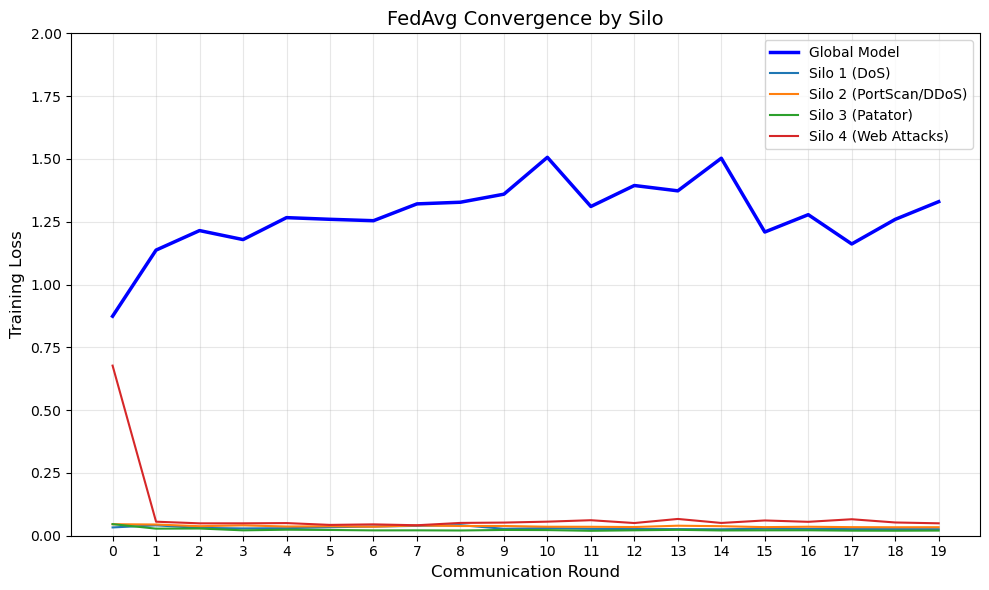

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(data['g_train_loss'], label='Global Model', linewidth=2.5, color='blue')
plt.plot(data['c_0_train_loss'], label='Silo 1 (DoS)', linewidth=1.5)
plt.plot(data['c_1_train_loss'], label='Silo 2 (PortScan/DDoS)', linewidth=1.5)
plt.plot(data['c_2_train_loss'], label='Silo 3 (Patator)', linewidth=1.5)
plt.plot(data['c_3_train_loss'], label='Silo 4 (Web Attacks)', linewidth=1.5)
plt.xticks(np.arange(0,20,1))
plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('FedAvg Convergence by Silo', fontsize=14)
plt.ylim(0,2)
plt.grid(True, alpha=0.3)  # ← add grid for readability
plt.tight_layout()
plt.legend()
plt.savefig('../modelperformance/fedavgtrain.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()


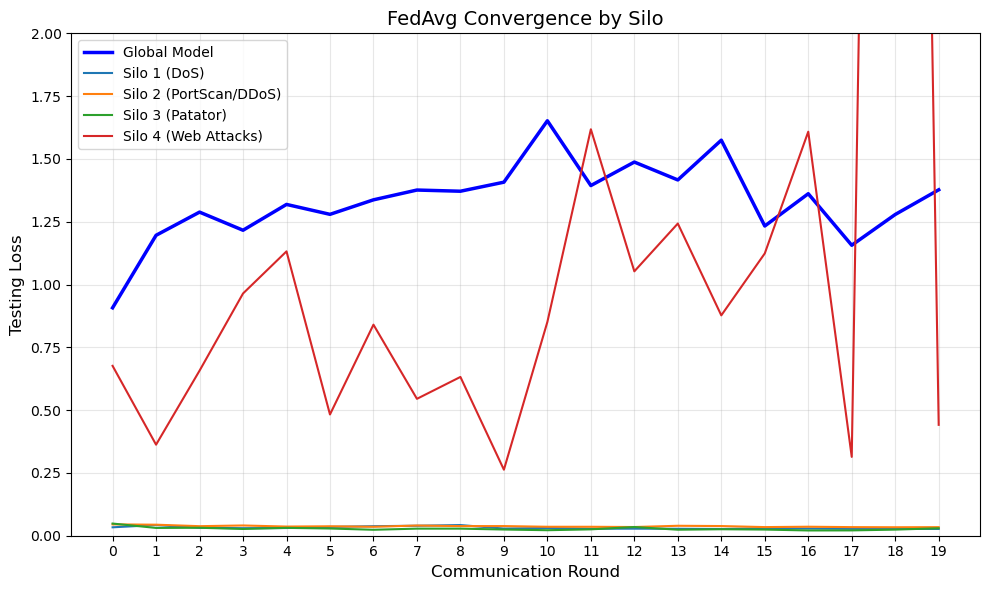

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(data['g_test_loss'], label='Global Model', linewidth=2.5, color='blue')
plt.plot(data['c_0_test_loss'], label='Silo 1 (DoS)', linewidth=1.5)
plt.plot(data['c_1_test_loss'], label='Silo 2 (PortScan/DDoS)', linewidth=1.5)
plt.plot(data['c_2_test_loss'], label='Silo 3 (Patator)', linewidth=1.5)
plt.plot(data['c_3_test_loss'], label='Silo 4 (Web Attacks)', linewidth=1.5)
plt.xticks(np.arange(0,20,1))
plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Testing Loss', fontsize=12)
plt.title('FedAvg Convergence by Silo', fontsize=14)
plt.ylim(0,2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig('../modelperformance/fedavgtest.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()

In [37]:
path = '../models/'
log_path = os.path.join(path, 'fedavg.pickle')
utils.savein_pickle(log_path, global_model)